# Nielsen Market Share Analysis
**AGR Consulting | Personal Care Category | Luminos Brand**

---

## Business Context

Luminos is a mid-size personal care brand (shampoo & body wash) competing against Dove, Pantene, Suave, and Private Label across 10 US markets and 3 retail channels (Food, Mass, Drug).

AGR Consulting has been engaged to diagnose Luminos's national dollar share performance and identify markets at risk. This notebook covers:

1. **National share overview** — How is Luminos performing vs. the category?
2. **Market-level trend analysis** — Which markets are declining, stable, or growing?
3. **Market classification** — Data-driven segmentation by share slope
4. **Competitive context** — Who is gaining where Luminos is losing?
5. **Regional patterns** — Is there a geographic concentration to the problem?

**Data:** `nielsen_weekly.csv` — 104 weeks (Jan 2023–Dec 2024), 5 brands, 10 markets, 3 channels

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import warnings
from scipy import stats

warnings.filterwarnings('ignore')

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
})

# ── Brand colors ───────────────────────────────────────────────────────────────
BRAND_COLORS = {
    'Luminos':       '#2563EB',   # blue  — our brand
    'Dove':          '#DC2626',   # red
    'Pantene':       '#D97706',   # amber
    'Suave':         '#059669',   # green
    'Private Label': '#6B7280',   # gray
}

MARKET_TYPE_COLORS = {
    'declining': '#DC2626',
    'stable':    '#6B7280',
    'growing':   '#059669',
}

print('Setup complete.')

Setup complete.


In [2]:
df = pd.read_csv('../data/nielsen_weekly.csv', parse_dates=['week_end_date'])

print(f'Shape: {df.shape}')
print(f'Weeks: {df["week_end_date"].min().date()} → {df["week_end_date"].max().date()}')
print(f'Brands: {sorted(df["brand"].unique())}')
print(f'Markets: {sorted(df["market"].unique())}')
print(f'Channels: {sorted(df["channel"].unique())}')
print()
df.head()

Shape: (15600, 18)
Weeks: 2023-01-07 → 2024-12-28
Brands: ['Dove', 'Luminos', 'Pantene', 'Private Label', 'Suave']
Markets: ['Chicago', 'Dallas', 'Detroit', 'Houston', 'Los Angeles', 'New York', 'Philadelphia', 'Phoenix', 'San Antonio', 'Seattle']
Channels: ['Drug', 'Food', 'Mass']



,week_end_date,week_index,market,region,channel,brand,dollar_sales,unit_sales,regular_price,effective_price,on_promo,pct_sales_on_promo,total_dollar_sales,total_unit_sales,dollar_share,unit_share,acv_distribution,velocity
0,2023-01-07,0,New York,Northeast,Food,Luminos,1730.00,266.56,6.49,6.4900,False,0.0000,12624.83,2210.27,0.1370,0.1206,0.7253,23.8522
1,2023-01-07,0,New York,Northeast,Food,Dove,4772.18,786.55,7.29,6.0673,True,0.7624,12624.83,2210.27,0.3780,0.3559,0.9324,51.1817
2,2023-01-07,0,New York,Northeast,Food,Suave,2105.61,421.97,4.99,4.9900,False,0.0000,12624.83,2210.27,0.1668,0.1909,0.9150,23.0121
3,2023-01-07,0,New York,Northeast,Food,Pantene,2576.73,322.49,7.99,7.9900,False,0.0000,12624.83,2210.27,0.2041,0.1459,0.8838,29.1551
4,2023-01-07,0,New York,Northeast,Food,Private Label,1440.31,412.70,3.49,3.4900,False,0.0000,12624.83,2210.27,0.1141,0.1867,0.8480,16.9848


In [4]:
# Quick sanity checks
print('=== Sanity Checks ===')
print(f'Null values: {df.isnull().sum().sum()}')
print(f'Unique weeks: {df["week_end_date"].nunique()} (expected 104)')
print(f'Unique brand × market × channel × week combos: {df[["brand","market","channel","week_end_date"]].drop_duplicates().shape[0]}')
print(f'Expected: {5 * 10 * 3 * 104} = {5*10*3*104}')
print()

# Dollar share sums to 1.0 per week × market × channel
share_check = (
    df.groupby(['week_end_date','market','channel'])['dollar_share']
    .sum()
    .round(2)
)
print(f'Dollar share sums to 1.0 in all groups: {(share_check == 1.0).all()}')

=== Sanity Checks ===
Null values: 0
Unique weeks: 104 (expected 104)
Unique brand × market × channel × week combos: 15600
Expected: 15600 = 15600

Dollar share sums to 1.0 in all groups: True


In [5]:
# Aggregate all weeks × markets × channels to get national dollar share
national_share = (
    df.groupby('brand')[['dollar_sales','unit_sales']]
    .sum()
    .assign(
        dollar_share = lambda x: x['dollar_sales'] / x['dollar_sales'].sum(),
        unit_share   = lambda x: x['unit_sales']   / x['unit_sales'].sum()
    )
    .sort_values('dollar_share', ascending=False)
    .reset_index()
)

print('National Dollar & Unit Share (2-year average):')
print(national_share[['brand','dollar_share','unit_share']]
      .to_string(index=False, float_format='{:.1%}'.format))

National Dollar & Unit Share (2-year average):
        brand  dollar_share  unit_share
         Dove         30.0%       25.0%
      Pantene         24.2%       18.1%
        Suave         19.4%       24.1%
      Luminos         14.6%       13.3%
Private Label         11.8%       19.6%


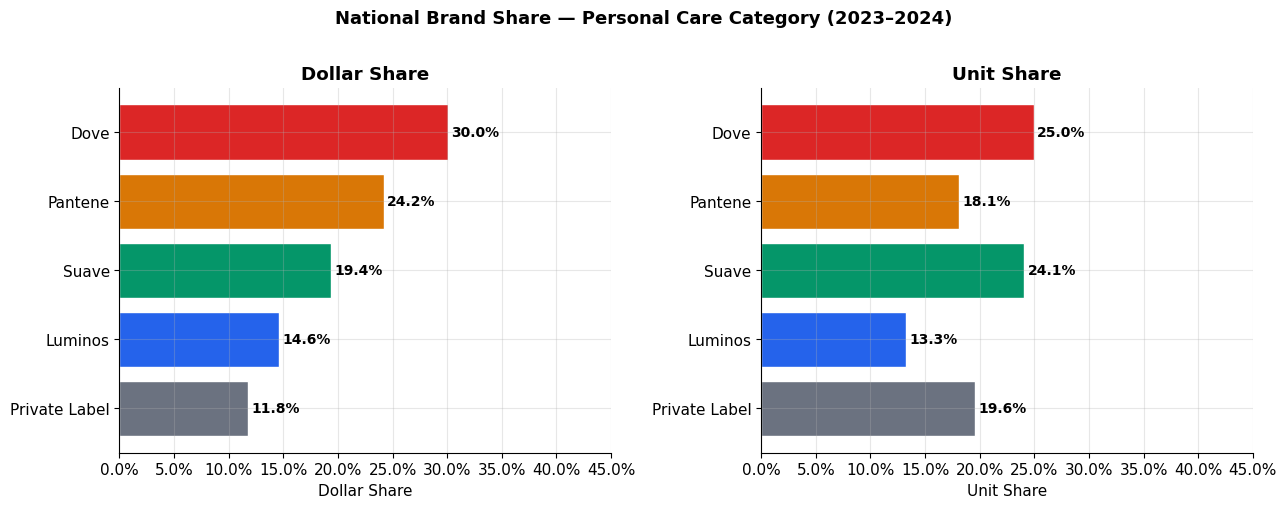

Chart saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('National Brand Share — Personal Care Category (2023–2024)', fontsize=13, fontweight='bold', y=1.01)

for ax, metric, title in zip(
    axes,
    ['dollar_share', 'unit_share'],
    ['Dollar Share', 'Unit Share']
):
    colors = [BRAND_COLORS[b] for b in national_share['brand']]
    bars = ax.barh(national_share['brand'], national_share[metric], color=colors, edgecolor='white')

    for bar, val in zip(bars, national_share[metric]):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.1%}', va='center', fontsize=10, fontweight='bold')

    ax.set_xlabel(title)
    ax.set_title(title, fontweight='bold')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlim(0, 0.45)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/01_national_share.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

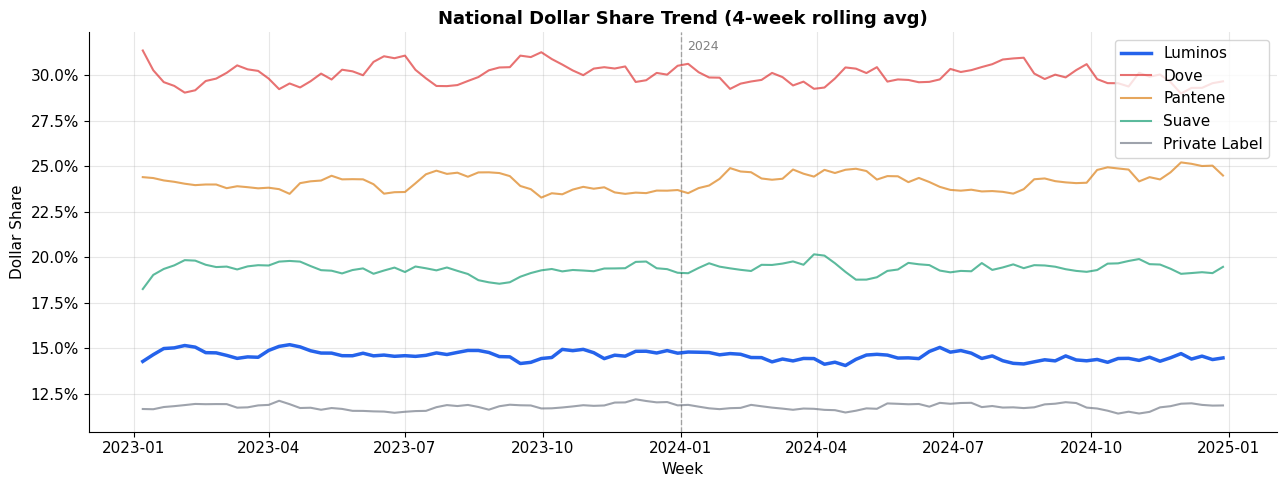

In [9]:
# National share TREND: weekly rolling 4-week avg to smooth noise
weekly_national = (
    df.groupby(['week_end_date','brand'])[['dollar_sales']]
    .sum()
    .reset_index()
)
weekly_national['total_sales'] = weekly_national.groupby('week_end_date')['dollar_sales'].transform('sum')
weekly_national['dollar_share'] = weekly_national['dollar_sales'] / weekly_national['total_sales']

# 4-week rolling average
weekly_national = weekly_national.sort_values(['brand','week_end_date'])
weekly_national['share_4w_ma'] = (
    weekly_national.groupby('brand')['dollar_share']
    .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

fig, ax = plt.subplots(figsize=(13, 5))

for brand in ['Luminos','Dove','Pantene','Suave','Private Label']:
    sub = weekly_national[weekly_national['brand'] == brand]
    lw  = 2.5 if brand == 'Luminos' else 1.5
    ax.plot(sub['week_end_date'], sub['share_4w_ma'],
            color=BRAND_COLORS[brand], label=brand, linewidth=lw,
            alpha=1.0 if brand == 'Luminos' else 0.65)

# Year divider
ax.axvline(pd.Timestamp('2024-01-01'), color='black', linestyle='--', alpha=0.3, linewidth=1)
ax.text(pd.Timestamp('2024-01-05'), ax.get_ylim()[1]*0.97, '2024', fontsize=9, color='gray')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('National Dollar Share Trend (4-week rolling avg)', fontsize=13, fontweight='bold')
ax.set_xlabel('Week')
ax.set_ylabel('Dollar Share')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('../outputs/01_national_share_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Aggregate across channels for market-level view (standard Nielsen practice)
luminos_weekly = (
    df[df['brand'] == 'Luminos']
    .groupby(['week_end_date','week_index','market','region'])[['dollar_sales']]
    .sum()
    .reset_index()
)

# Category total per week × market (all brands)
cat_weekly = (
    df.groupby(['week_end_date','week_index','market'])[['dollar_sales']]
    .sum()
    .rename(columns={'dollar_sales':'cat_dollar_sales'})
    .reset_index()
)

luminos_weekly = luminos_weekly.merge(cat_weekly, on=['week_end_date','week_index','market'])
luminos_weekly['dollar_share'] = (luminos_weekly['dollar_sales'] / luminos_weekly['cat_dollar_sales']).round(4)

# 4-week rolling average
luminos_weekly = luminos_weekly.sort_values(['market','week_end_date'])
luminos_weekly['share_4w_ma'] = (
    luminos_weekly.groupby('market')['dollar_share']
    .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

print(f'Luminos weekly market-level data: {luminos_weekly.shape}')
luminos_weekly.head(3)

Luminos weekly market-level data: (1040, 8)


,week_end_date,week_index,market,region,dollar_sales,cat_dollar_sales,dollar_share,share_4w_ma
0,2023-01-07,0,Chicago,Midwest,4972.05,37864.65,0.1313,0.131300
10,2023-01-14,1,Chicago,Midwest,5834.52,36388.54,0.1603,0.145800
20,2023-01-21,2,Chicago,Midwest,6222.40,34496.76,0.1804,0.157333


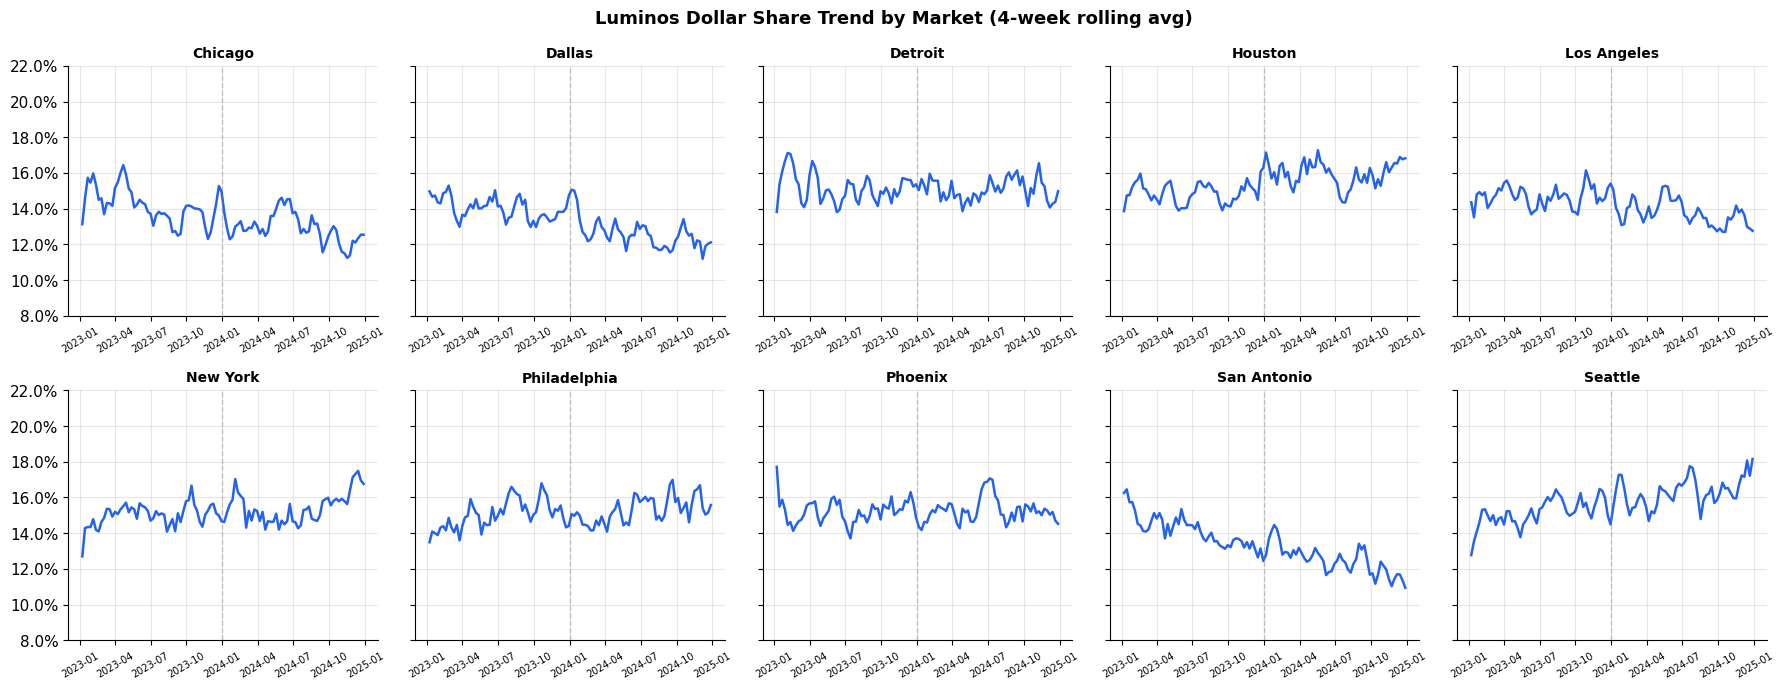

Visual inspection: look for markets with clear downward slopes.


In [11]:
# Plot Luminos share trend for all 10 markets
markets = sorted(luminos_weekly['market'].unique())

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=True)
fig.suptitle('Luminos Dollar Share Trend by Market (4-week rolling avg)', fontsize=13, fontweight='bold')

for ax, market in zip(axes.flat, markets):
    sub = luminos_weekly[luminos_weekly['market'] == market]
    ax.plot(sub['week_end_date'], sub['share_4w_ma'], color='#2563EB', linewidth=1.8)
    ax.axvline(pd.Timestamp('2024-01-01'), color='gray', linestyle='--', alpha=0.4, linewidth=1)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(market, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.set_ylim(0.08, 0.22)

plt.tight_layout()
plt.savefig('../outputs/01_market_share_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visual inspection: look for markets with clear downward slopes.')

In [12]:
# Fit OLS slope per market: dollar_share ~ week_index
slopes = []
for market, grp in luminos_weekly.groupby('market'):
    grp = grp.sort_values('week_index')
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        grp['week_index'], grp['dollar_share']
    )
    # Annualize: slope is per week, multiply by 52 → share points per year
    slope_annual_pp = slope * 52 * 100   # in percentage points
    slopes.append({
        'market':          market,
        'region':          grp['region'].iloc[0],
        'slope_weekly':    round(slope, 6),
        'slope_annual_pp': round(slope_annual_pp, 3),
        'r_squared':       round(r_value**2, 3),
        'p_value':         round(p_value, 4),
        'share_y1_avg':    round(grp[grp['week_index'] < 52]['dollar_share'].mean(), 4),
        'share_y2_avg':    round(grp[grp['week_index'] >= 52]['dollar_share'].mean(), 4),
    })

slope_df = pd.DataFrame(slopes).sort_values('slope_annual_pp')
slope_df['change_pp'] = (slope_df['share_y2_avg'] - slope_df['share_y1_avg']) * 100

# Classify
def classify_market(slope_pp):
    if slope_pp < -0.5:
        return 'declining'
    elif slope_pp > 0.3:
        return 'growing'
    else:
        return 'stable'

slope_df['market_type'] = slope_df['slope_annual_pp'].apply(classify_market)

print('Market Classification (data-driven, by share slope):')
print('─' * 75)
print(f'{"Market":<15} {"Region":<12} {"Slope (pp/yr)":>13} {"Y1 Share":>9} {"Y2 Share":>9} {"Δ pp":>7} {"Type":<10} {"p-value"}')
print('─' * 75)
for _, row in slope_df.iterrows():
    print(f'{row["market"]:<15} {row["region"]:<12} {row["slope_annual_pp"]:>13.3f} '
          f'{row["share_y1_avg"]:>8.1%} {row["share_y2_avg"]:>9.1%} '
          f'{row["change_pp"]:>6.2f} {row["market_type"]:<12} {row["p_value"]}')
print('─' * 75)
print()
print('Summary:')
print(slope_df['market_type'].value_counts().to_string())

Market Classification (data-driven, by share slope):
───────────────────────────────────────────────────────────────────────────
Market          Region       Slope (pp/yr)  Y1 Share  Y2 Share    Δ pp Type       p-value
───────────────────────────────────────────────────────────────────────────
San Antonio     South               -1.813    14.0%     12.4%  -1.63 declining    0.0
Dallas          South               -1.353    14.1%     12.5%  -1.58 declining    0.0
Chicago         Midwest             -1.306    14.2%     12.9%  -1.32 declining    0.0
Los Angeles     West                -0.850    14.7%     13.7%  -1.03 declining    0.0003
Detroit         Midwest             -0.143    15.2%     15.0%  -0.15 stable       0.5785
Phoenix         West                 0.102    15.2%     15.3%   0.12 stable       0.68
Philadelphia    Northeast            0.530    15.0%     15.3%   0.29 growing      0.0392
New York        Northeast            0.543    15.0%     15.5%   0.45 growing      0.0247
Hous

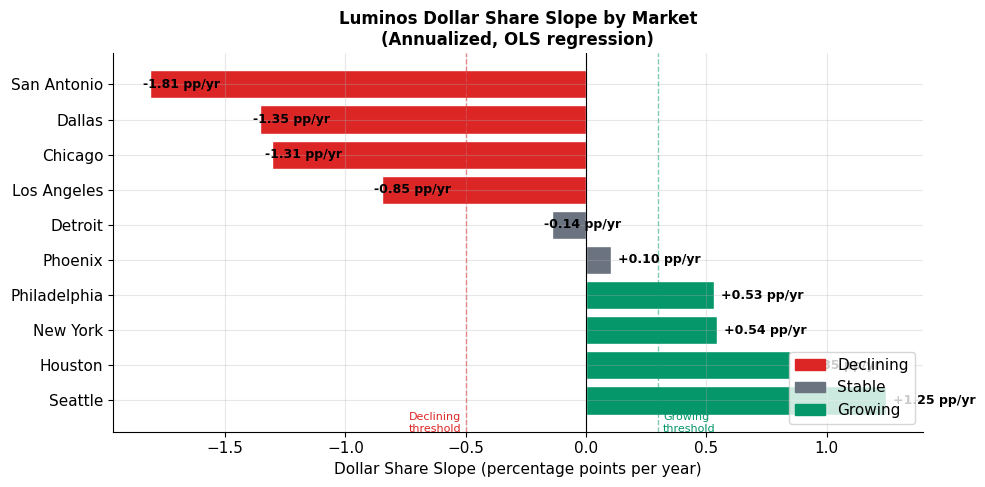

In [13]:
# Slope chart: ranked bar chart
fig, ax = plt.subplots(figsize=(10, 5))

colors = [MARKET_TYPE_COLORS[t] for t in slope_df['market_type']]
bars   = ax.barh(slope_df['market'], slope_df['slope_annual_pp'], color=colors, edgecolor='white')

for bar, val in zip(bars, slope_df['slope_annual_pp']):
    x_pos = bar.get_width() + (0.03 if val >= 0 else -0.03)
    ha    = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:+.2f} pp/yr', va='center', fontsize=9, fontweight='bold')

ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(-0.5, color='#DC2626', linewidth=1, linestyle='--', alpha=0.5)
ax.axvline( 0.3, color='#059669', linewidth=1, linestyle='--', alpha=0.5)

ax.text(-0.52, ax.get_ylim()[1], 'Declining\nthreshold', ha='right', fontsize=8, color='#DC2626')
ax.text( 0.32, ax.get_ylim()[1], 'Growing\nthreshold',  ha='left',  fontsize=8, color='#059669')

patches = [mpatches.Patch(color=MARKET_TYPE_COLORS[t], label=t.capitalize())
           for t in ['declining','stable','growing']]
ax.legend(handles=patches, loc='lower right')

ax.set_xlabel('Dollar Share Slope (percentage points per year)')
ax.set_title('Luminos Dollar Share Slope by Market\n(Annualized, OLS regression)', fontsize=12, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/01_market_slopes.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Compute Y1 vs Y2 share change for ALL brands in each market
df_merged = df.merge(slope_df[['market','market_type']], on='market')

brand_market_share = (
    df_merged
    .groupby(['market','market_type','brand','week_index'])[['dollar_sales']]
    .sum()
    .reset_index()
)

cat_totals = (
    brand_market_share
    .groupby(['market','week_index'])['dollar_sales']
    .sum().rename('cat_sales').reset_index()
)
brand_market_share = brand_market_share.merge(cat_totals, on=['market','week_index'])
brand_market_share['dollar_share'] = brand_market_share['dollar_sales'] / brand_market_share['cat_sales']
brand_market_share['year'] = brand_market_share['week_index'].apply(lambda x: 'Y1' if x < 52 else 'Y2')

share_pivot = (
    brand_market_share
    .groupby(['market','market_type','brand','year'])['dollar_share']
    .mean()
    .unstack('year')
    .assign(change_pp=lambda x: (x['Y2'] - x['Y1']) * 100)
    .reset_index()
)

# Focus on declining markets
declining_mkts = slope_df[slope_df['market_type'] == 'declining']['market'].tolist()
comp_dec = share_pivot[share_pivot['market'].isin(declining_mkts)].sort_values(['market','brand'])

print('Share Change (Y1→Y2) in DECLINING Markets (pp):')
pivot_display = comp_dec.pivot_table(index='brand', columns='market', values='change_pp').round(2)
pivot_display['AVG'] = pivot_display.mean(axis=1).round(2)
print(pivot_display.sort_values('AVG').to_string())

Share Change (Y1→Y2) in DECLINING Markets (pp):
market         Chicago  Dallas  Los Angeles  San Antonio   AVG
brand                                                         
Luminos          -1.32   -1.58        -1.03        -1.63 -1.39
Dove             -0.41    0.21         1.37        -0.11  0.26
Private Label     0.32    0.63        -0.32         0.46  0.27
Pantene           0.72    0.45         0.21         0.24  0.40
Suave             0.68    0.28        -0.22         1.05  0.45


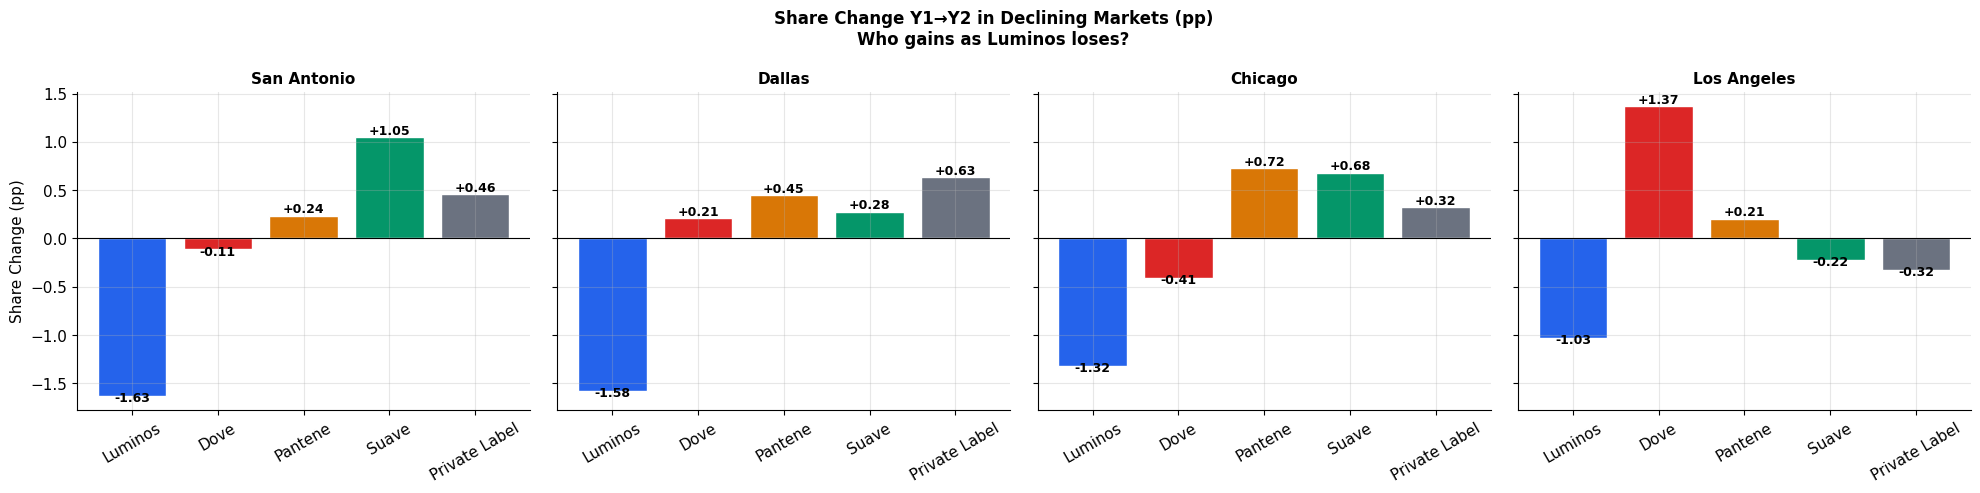

In [15]:
# Grouped bar chart: share change by brand in declining markets
fig, axes = plt.subplots(1, len(declining_mkts), figsize=(5*len(declining_mkts), 5), sharey=True)
if len(declining_mkts) == 1:
    axes = [axes]

fig.suptitle('Share Change Y1→Y2 in Declining Markets (pp)\nWho gains as Luminos loses?',
             fontsize=12, fontweight='bold')

brands_ordered = ['Luminos','Dove','Pantene','Suave','Private Label']

for ax, market in zip(axes, declining_mkts):
    sub = comp_dec[comp_dec['market'] == market].set_index('brand')
    changes = [sub.loc[b, 'change_pp'] if b in sub.index else 0 for b in brands_ordered]
    colors  = [BRAND_COLORS[b] for b in brands_ordered]

    bars = ax.bar(brands_ordered, changes, color=colors, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)

    for bar, val in zip(bars, changes):
        y_pos = val + (0.03 if val >= 0 else -0.06)
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f'{val:+.2f}', ha='center', fontsize=9, fontweight='bold')

    ax.set_title(market, fontsize=11, fontweight='bold')
    ax.set_ylabel('Share Change (pp)' if market == declining_mkts[0] else '')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/01_competitive_gainers.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Average slope by region
regional_summary = (
    slope_df.groupby('region')
    .agg(
        avg_slope_pp      = ('slope_annual_pp', 'mean'),
        n_markets         = ('market', 'count'),
        n_declining       = ('market_type', lambda x: (x == 'declining').sum()),
        n_growing         = ('market_type', lambda x: (x == 'growing').sum()),
        avg_share_y1      = ('share_y1_avg', 'mean'),
        avg_share_y2      = ('share_y2_avg', 'mean'),
    )
    .assign(avg_change_pp=lambda x: (x['avg_share_y2'] - x['avg_share_y1']) * 100)
    .sort_values('avg_slope_pp')
    .reset_index()
)

print('Regional Summary:')
print(regional_summary.to_string(index=False, float_format='{:.3f}'.format))

Regional Summary:
   region  avg_slope_pp  n_markets  n_declining  n_growing  avg_share_y1  avg_share_y2  avg_change_pp
    South        -0.772          3            2          1         0.144         0.136         -0.747
  Midwest        -0.725          2            1          0         0.147         0.140         -0.735
     West         0.166          3            1          1         0.150         0.151          0.120
Northeast         0.536          2            0          2         0.150         0.154          0.370


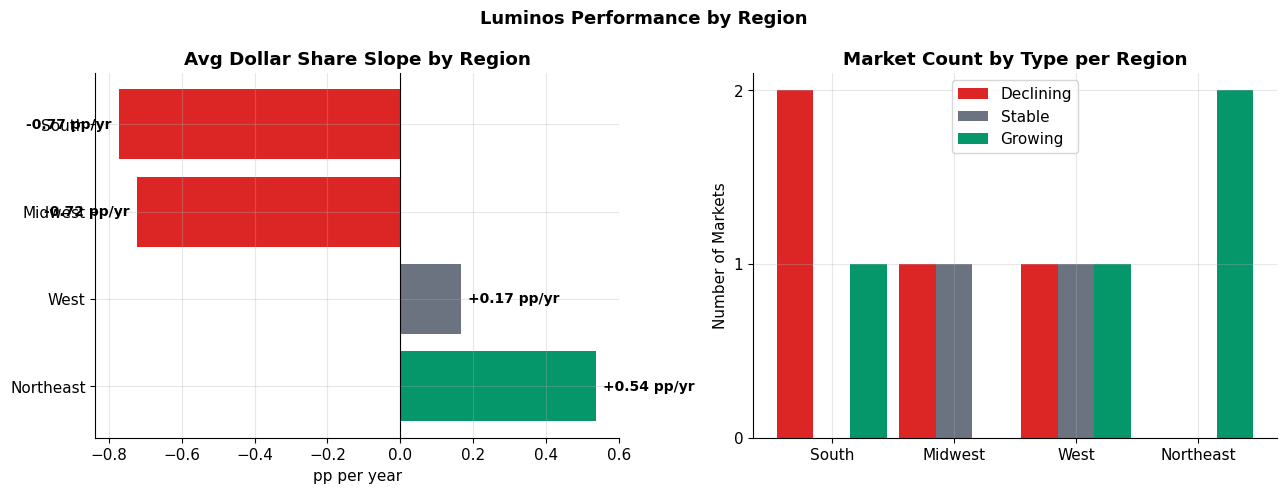

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Luminos Performance by Region', fontsize=13, fontweight='bold')

# Left: avg slope by region
ax = axes[0]
colors = [MARKET_TYPE_COLORS['declining'] if v < -0.5 else
          MARKET_TYPE_COLORS['growing'] if v > 0.3 else
          MARKET_TYPE_COLORS['stable']
          for v in regional_summary['avg_slope_pp']]
bars = ax.barh(regional_summary['region'], regional_summary['avg_slope_pp'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, regional_summary['avg_slope_pp']):
    x = bar.get_width() + (0.02 if val >= 0 else -0.02)
    ax.text(x, bar.get_y() + bar.get_height()/2, f'{val:+.2f} pp/yr',
            va='center', ha='left' if val >= 0 else 'right', fontsize=10, fontweight='bold')
ax.set_title('Avg Dollar Share Slope by Region', fontweight='bold')
ax.set_xlabel('pp per year')
ax.invert_yaxis()

# Right: market count by type per region
ax = axes[1]
x = np.arange(len(regional_summary))
width = 0.3
ax.bar(x - width, regional_summary['n_declining'], width, label='Declining', color=MARKET_TYPE_COLORS['declining'])
ax.bar(x,         regional_summary['n_markets'] - regional_summary['n_declining'] - regional_summary['n_growing'],
       width, label='Stable', color=MARKET_TYPE_COLORS['stable'])
ax.bar(x + width, regional_summary['n_growing'],  width, label='Growing',  color=MARKET_TYPE_COLORS['growing'])
ax.set_xticks(x)
ax.set_xticklabels(regional_summary['region'])
ax.set_title('Market Count by Type per Region', fontweight='bold')
ax.set_ylabel('Number of Markets')
ax.legend()
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('../outputs/01_regional_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Auto-generate findings from data
luminos_nat_share = national_share[national_share['brand']=='Luminos']['dollar_share'].values[0]
luminos_rank      = national_share['brand'].tolist().index('Luminos') + 1
n_declining       = (slope_df['market_type'] == 'declining').sum()
n_growing         = (slope_df['market_type'] == 'growing').sum()
worst_market      = slope_df.iloc[0]
best_gainer_dec   = pivot_display.drop('AVG', axis=1)[declining_mkts].drop('Luminos').mean(axis=1).idxmax()
worst_region      = regional_summary.sort_values('avg_slope_pp').iloc[0]

print('=' * 65)
print('  KEY FINDINGS — Luminos Market Share Analysis')
print('=' * 65)
print(f"""
1. NATIONAL POSITION
   Luminos holds {luminos_nat_share:.1%} national dollar share,
   ranking #{luminos_rank} behind Dove ({national_share[national_share['brand']=='Dove']['dollar_share'].values[0]:.1%})
   and Pantene ({national_share[national_share['brand']=='Pantene']['dollar_share'].values[0]:.1%}).

2. MARKET PERFORMANCE SPLIT
   Of 10 markets, {n_declining} are declining, {n_growing} are growing, and
   {10 - n_declining - n_growing} are stable based on share slope analysis.

3. WORST MARKET
   {worst_market['market']} is the most challenged market, with Luminos
   dollar share declining at {worst_market['slope_annual_pp']:.2f} pp per year
   ({worst_market['share_y1_avg']:.1%} in Y1 → {worst_market['share_y2_avg']:.1%} in Y2).

4. COMPETITIVE THREAT
   {best_gainer_dec} is the primary beneficiary of Luminos share loss
   in declining markets.

5. REGIONAL PATTERN
   The {worst_region['region']} region shows the steepest average decline
   ({worst_region['avg_slope_pp']:.2f} pp/yr), with {int(worst_region['n_declining'])} of
   {int(worst_region['n_markets'])} markets classified as declining.

6. NEXT STEP
   Share loss diagnosis is incomplete without understanding WHETHER
   the problem is distribution (ACV), shelf velocity, or pricing/promo.
   → See Notebook 02: Distribution & Velocity Analysis
""")
print('=' * 65)

  KEY FINDINGS — Luminos Market Share Analysis

1. NATIONAL POSITION
   Luminos holds 14.6% national dollar share,
   ranking #4 behind Dove (30.0%)
   and Pantene (24.2%).

2. MARKET PERFORMANCE SPLIT
   Of 10 markets, 4 are declining, 4 are growing, and
   2 are stable based on share slope analysis.

3. WORST MARKET
   San Antonio is the most challenged market, with Luminos
   dollar share declining at -1.81 pp per year
   (14.0% in Y1 → 12.4% in Y2).

4. COMPETITIVE THREAT
   Suave is the primary beneficiary of Luminos share loss
   in declining markets.

5. REGIONAL PATTERN
   The South region shows the steepest average decline
   (-0.77 pp/yr), with 2 of
   3 markets classified as declining.

6. NEXT STEP
   Share loss diagnosis is incomplete without understanding WHETHER
   the problem is distribution (ACV), shelf velocity, or pricing/promo.
   → See Notebook 02: Distribution & Velocity Analysis



In [20]:
# Save market classification for use in downstream notebooks
slope_df[['market','region','market_type','slope_annual_pp','share_y1_avg','share_y2_avg','change_pp','p_value']]\
    .to_csv('../data/market_classification.csv', index=False)
print('Saved: ../data/market_classification.csv')
print('This file is the input to Notebooks 02 and 03.')

Saved: ../data/market_classification.csv
This file is the input to Notebooks 02 and 03.
